In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
df=pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


In [39]:
df.describe()

,Weight,Height
count,23.000000,23.000000
mean,73.826087,158.391304
std,17.872407,19.511626
min,45.000000,120.000000
25%,59.000000,142.500000
50%,78.000000,162.000000
75%,86.000000,175.000000
max,105.000000,183.000000


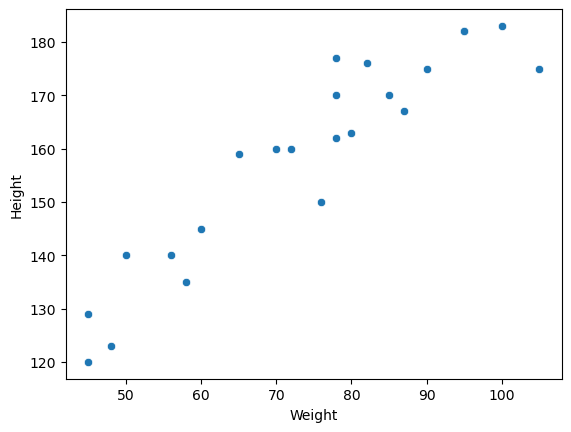

In [40]:
sns.scatterplot(x=df['Weight'],y=df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.show()

In [41]:
#  independent and dependent features
X=df[['Weight']]  #independent
y=df['Height']  #dependent

In [61]:
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


In [42]:
# train-test split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [43]:
X.shape,X_train.shape,X_test.shape

((23, 1), (18, 1), (5, 1))

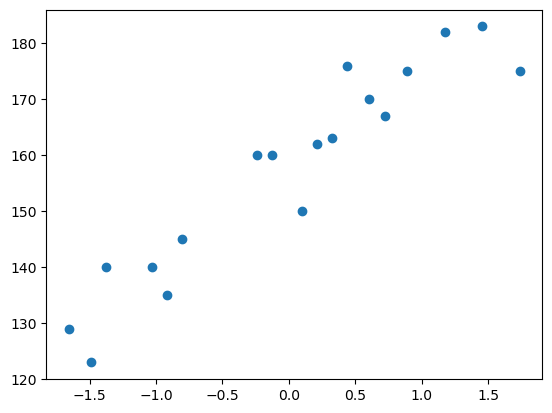

In [44]:
# standardization --- important for smooth gradient descent 
#  for distance based or optimization base
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train) # fit :- compute mean and std dev , transform :- apply z-score to all values
X_test=scaler.transform(X_test) # apply z score using trained data mean and std dev
plt.scatter(X_train,y_train)


In [45]:
#  train the model
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [46]:
print("The slope or coefficient of weight is ",model.coef_)
print("Intercept: ",model.intercept_)

The slope or coefficient of weight is  [17.03440872]
Intercept:  157.5


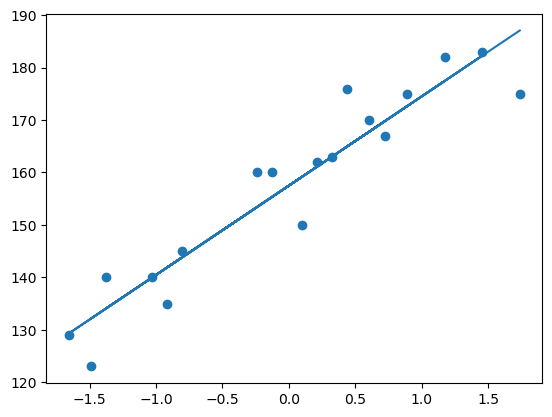

In [50]:
plt.scatter(X_train,y_train)
plt.plot(X_train,model.predict(X_train))

In [51]:
y_pred=model.predict(X_test)
y_pred,y_test


(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

In [53]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
score=r2_score(y_test,y_pred)
print(mse)
print(mae)
print(rmse)
print(score)

109.77592599051664
9.822657814519232
10.477400726827081
0.776986986042344


In [54]:
# adjusted r2_score
1-(1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)


0.7026493147231252

In [55]:
# new predicted data
new=scaler.transform([[43]])
new

c:\Users\yashi\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-1.76829946]])

In [ ]:
print("The height prediction of 43kg weight is ",model.predict(new))

[127.3780643]


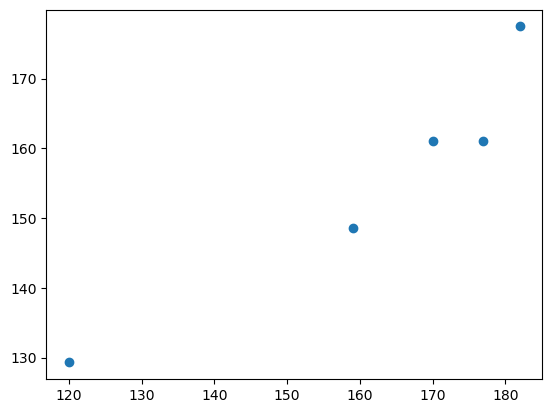

In [58]:
plt.scatter(y_test,y_pred)

In [59]:
# Residuals
residuals = y_test - y_pred
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

C:\Users\yashi\AppData\Local\Temp\ipykernel_21668\3762910054.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals,kde=True)


<Axes: xlabel='Height', ylabel='Density'>

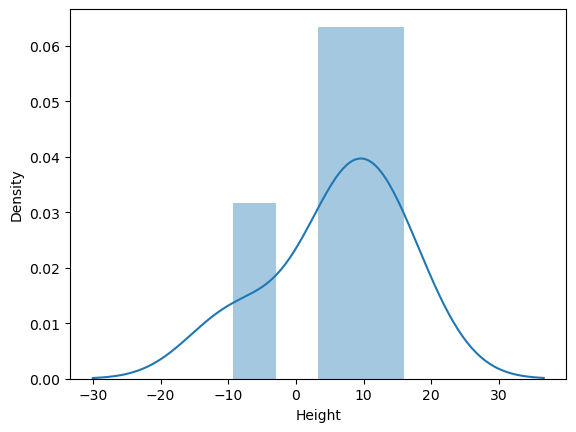

In [60]:
sns.distplot(residuals,kde=True)

In [ ]:
# pickling the model 